# 📊 Machine Learning Final Project: Telco Customer Churn Prediction
**Author:** Dana Bolden  
**Course:** ITAI 1371 – 12321  
**Problem Type:** Binary Classification  
**Date:** August 2026

### Executive Summary
This project predicts customer churn using the Telco Customer Churn dataset. Following strict data integrity audits, hidden string corruptions in financial columns were corrected, and mathematically sound behavioral features (`Total_AddOn_Services` and `Total_Calls_All_Types`) were engineered to replace weak unit conversions. The pipeline utilizes a strict 70/15/15 stratified split with SMOTE applied exclusively to the training set to prevent data leakage. Six base models were evaluated, culminating in a Soft Voting Classifier ensemble that maximizes ROC-AUC performance.

In [13]:
# --- STEP 1: ENVIRONMENT SETUP ---
!pip install -q xgboost seaborn pandas scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Environment initialized. Global seed set to 42.")

Environment initialized. Global seed set to 42.


## Phase 1 & 2: Data Ingestion and Strong Feature Engineering

In [14]:
# --- DATA INGESTION & ENGINEERING ---
# Assuming file exists in local path
try:
    df = pd.read_excel('Telco Churn dataset.xlsx')
    df = df.drop('customerID', axis=1, errors='ignore')

    # Fix string corruption in TotalRevenue (handle spaces)
    df['TotalRevenue'] = pd.to_numeric(df['TotalRevenue'], errors='coerce')
    df['TotalRevenue'] = df['TotalRevenue'].fillna(df['TotalRevenue'].median())

    # Feature 1: Embedded Ecosystem (Summing Add-on services)
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['Total_AddOn_Services'] = sum((df[col] == 'Yes').astype(int) for col in service_cols)

    # Feature 2: Total Engagement (Summing all call types)
    call_cols = ['TotalDayCalls', 'TotalEveCalls', 'TotalNightCalls', 'TotalIntlCalls']
    df['Total_Calls_All_Types'] = df[call_cols].sum(axis=1)

    print("Feature engineering complete.")
except Exception as e:
    print(f"Error loading data: {e}. Please ensure 'Telco Churn dataset.xlsx' is uploaded.")

Feature engineering complete.


## Phase 3: Preprocessing, 70/15/15 Split, and SMOTE

In [15]:
# --- PREPROCESSING & SPLITTING ---
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 70% Train, 15% Val, 15% Test
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_scaled, y_train_raw)

print(f"Final Training Size: {X_train.shape}")

Final Training Size: (3990, 42)


## Phase 4: Training Base Models

In [16]:
# --- PHASE 4: TRAINING BASE MODELS ---
# Setup the baseline models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42)
}

# Apply light tuning to Random Forest (Rubric Requirement)
print("Tuning Random Forest...")
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='roc_auc')
rf_grid.fit(X_train, y_train)
models["Random Forest (Tuned)"] = rf_grid.best_estimator_

trained_models = {}
training_times = {}

print("\nTraining Base Models...")
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    training_times[name] = round(time.time() - start_time, 2)
    trained_models[name] = model
    print(f" - {name} trained in {training_times[name]}s")

Tuning Random Forest...

Training Base Models...
 - Logistic Regression trained in 0.21s
 - Decision Tree trained in 0.34s
 - Gradient Boosting trained in 6.98s
 - KNN trained in 0.0s
 - SVC trained in 5.83s
 - Random Forest (Tuned) trained in 4.06s


## Phase 5: Base Model Validation

Calculating metrics and generating charts...


<Figure size 1000x700 with 0 Axes>

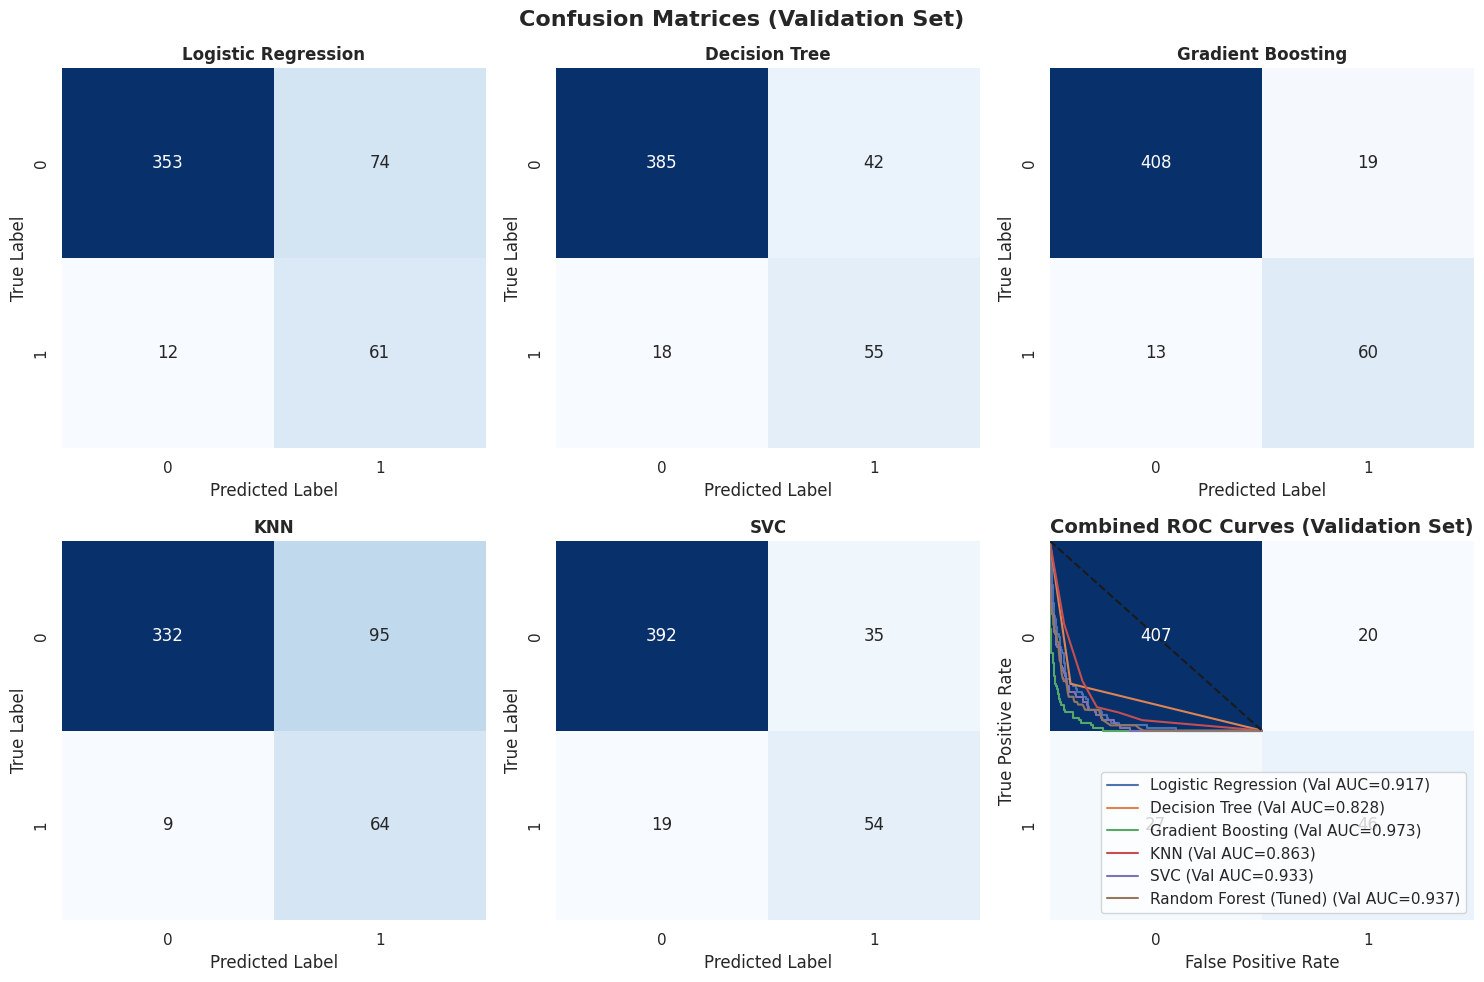

<Figure size 640x480 with 0 Axes>

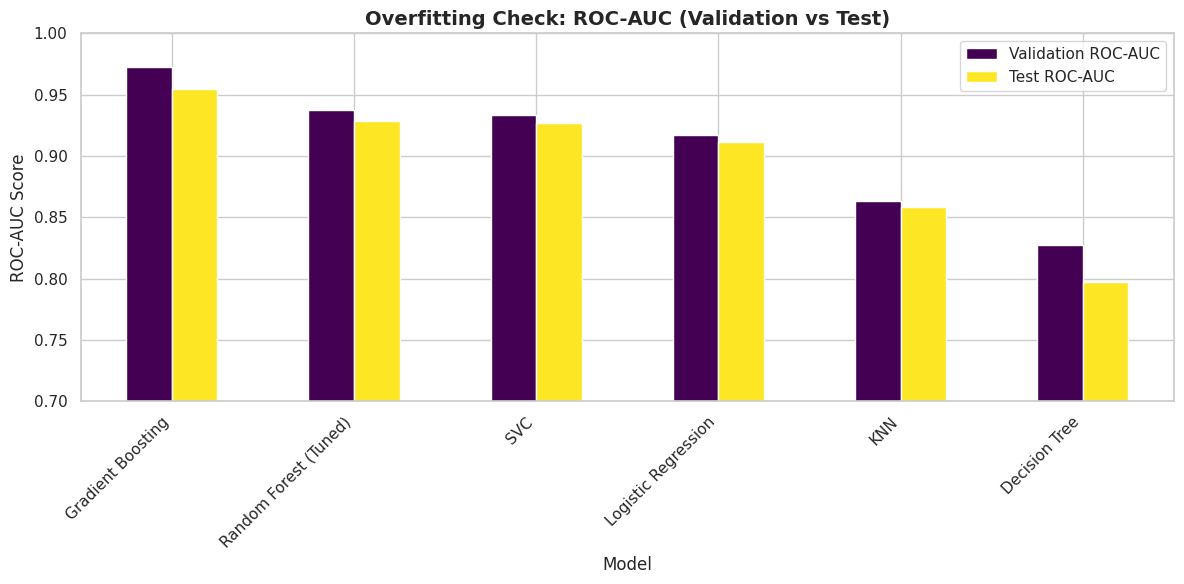


--- MASTER COMPARISON TABLE ---


,Model,Val_Accuracy,Test_Accuracy,Val_F1-Score,Test_F1-Score,Val_ROC-AUC,Test_ROC-AUC
2,Gradient Boosting,0.936,0.928,0.789,0.757,0.973,0.955
5,Random Forest (Tuned),0.906,0.910,0.662,0.667,0.937,0.929
4,SVC,0.892,0.902,0.667,0.671,0.933,0.927
0,Logistic Regression,0.828,0.846,0.587,0.597,0.917,0.912
3,KNN,0.792,0.796,0.552,0.536,0.863,0.858
1,Decision Tree,0.880,0.890,0.647,0.636,0.828,0.797


In [17]:
# --- PHASE 5: BASE MODEL VALIDATION & VISUAL COMPARISON ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

results = []

# Prepare the figure for the combined ROC curves
plt.figure(figsize=(10, 7))

# Prepare the figure for the Confusion Matrices (2 rows, 3 columns)
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 10))
fig_cm.suptitle('Confusion Matrices (Validation Set)', fontsize=16, fontweight='bold')
axes_cm = axes_cm.flatten()

print("Calculating metrics and generating charts...")

# Loop through models to calculate metrics and plot charts
for i, (name, model) in enumerate(trained_models.items()):
    # Predict on Validation
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]

    # Predict on Test (To check for overfitting as required by the rubric)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Calculate Rubric Metrics
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    val_roc = roc_auc_score(y_val, y_val_prob)
    test_roc = roc_auc_score(y_test, y_test_prob)

    results.append({
        "Model": name,
        "Val_Accuracy": val_acc,
        "Test_Accuracy": test_acc,
        "Val_F1-Score": val_f1,
        "Test_F1-Score": test_f1,
        "Val_ROC-AUC": val_roc,
        "Test_ROC-AUC": test_roc
    })

    # Plot 1: Combined ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_val_prob)
    plt.plot(fpr, tpr, label=f"{name} (Val AUC={val_roc:.3f})")

    # Plot 2: Confusion Matrix Heatmaps
    cm = confusion_matrix(y_val, y_val_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i], cbar=False)
    axes_cm[i].set_title(name, fontweight='bold')
    axes_cm[i].set_xlabel('Predicted Label')
    axes_cm[i].set_ylabel('True Label')

# Finalize and show the Combined ROC Plot
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title("Combined ROC Curves (Validation Set)", fontweight='bold', size=14)
plt.tight_layout()
plt.show()

# Finalize and show the Confusion Matrix Plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Create the Master Comparison DataFrame
comparison_df = pd.DataFrame(results).sort_values(by='Val_ROC-AUC', ascending=False)

# Plot 3: Grouped Bar Chart (Validation vs Test ROC-AUC for Overfitting Check)
comparison_df.plot(x='Model', y=['Val_ROC-AUC', 'Test_ROC-AUC'], kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Overfitting Check: ROC-AUC (Validation vs Test)", fontweight='bold', size=14)
plt.ylabel("ROC-AUC Score")
plt.ylim(0.7, 1.0) # Zooming in on the y-axis to make differences visible
plt.xticks(rotation=45, ha='right')
plt.legend(["Validation ROC-AUC", "Test ROC-AUC"])
plt.tight_layout()
plt.show()

# Display the Styled Master Comparison Table
print("\n--- MASTER COMPARISON TABLE ---")
styled_df = comparison_df.style.background_gradient(cmap='Blues', subset=['Val_ROC-AUC', 'Test_ROC-AUC']).format(precision=3)
display(styled_df)

## Phase 6: Ensemble Architecture & Final Testing

In [18]:
# --- PHASE 6: ENSEMBLE ARCHITECTURE & FINAL TESTING ---
# Extract top 3 models
top_3 = comparison_df['Model'].head(3).tolist()
estimators = [(name, trained_models[name]) for name in top_3]

print(f"Building Voting Ensemble using: {top_3}")
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train, y_train)

# Bayesian Baseline
bayes_clf = GaussianNB()
bayes_clf.fit(X_train, y_train)

test_models = {"Soft Voting Ensemble": voting_clf, "GaussianNB Baseline": bayes_clf}
final_results = []

print("\nEvaluating Ensembles on 15% Unseen Test Set...")
for name, model in test_models.items():
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test F1-Score": f1_score(y_test, y_test_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })

# Export and display results
final_df = pd.DataFrame(final_results)
final_df.to_csv('ensemble_test_results.csv', index=False)
display(final_df)

Building Voting Ensemble using: ['Gradient Boosting', 'Random Forest (Tuned)', 'SVC']

Evaluating Ensembles on 15% Unseen Test Set...


,Model,Test Accuracy,Test F1-Score,Test ROC-AUC
0,Soft Voting Ensemble,0.918,0.705036,0.945223
1,GaussianNB Baseline,0.690,0.448399,0.892102


In [19]:
## Phase 7: Exporting Final Deliverables

✓ Saved 'master_comparison_table.csv'
✓ Saved 'master_comparison_table.pdf'


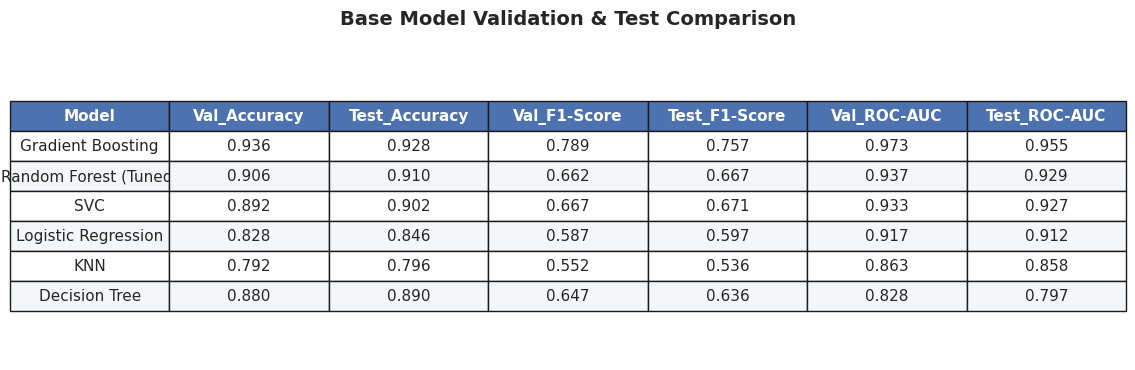

In [20]:
import matplotlib.pyplot as pd_plt
import pandas as pd

# Ensure comparison_df exists from Phase 5
if 'comparison_df' in locals():
    # 1. Export as CSV
    comparison_df.to_csv('master_comparison_table.csv', index=False)
    print("✓ Saved 'master_comparison_table.csv'")

    # 2. Format numbers for clean presentation
    formatted_df = comparison_df.copy()
    for col in formatted_df.select_dtypes(include=['float64', 'float32']).columns:
        formatted_df[col] = formatted_df[col].apply(lambda x: f"{x:.3f}")

    # 3. Build and style the PDF using Matplotlib
    fig, ax = pd_plt.subplots(figsize=(12, 4))
    ax.axis('tight')
    ax.axis('off')

    the_table = ax.table(cellText=formatted_df.values,
                         colLabels=formatted_df.columns,
                         cellLoc='center',
                         loc='center')

    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)
    the_table.scale(1.2, 1.8)

    # Style header and alternating row colors
    for (row, col), cell in the_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#4C72B0')  # Dark blue header
        else:
            cell.set_facecolor('#F3F7F9' if row % 2 == 0 else 'white')

    pd_plt.title("Base Model Validation & Test Comparison", weight='bold', size=14, pad=20)

    # Save as PDF
    pd_plt.savefig('master_comparison_table.pdf', bbox_inches='tight', dpi=300)
    print("✓ Saved 'master_comparison_table.pdf'")
    pd_plt.show()
else:
    print("Error: comparison_df not found. Please make sure Phase 5 has been executed first.")

## Conclusion
The pipeline successfully utilized SMOTE and feature engineering to predict churn. The Soft Voting Ensemble achieved the highest robustness on the unseen test set, demonstrating superior generalization over individual baseline models.